In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

You will use this baseball dataset for all of the plotting questions in the lab.

In [2]:
bb = pd.read_csv("./data/Hitters.csv")
bb.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


# Lab: pyplot vs Axes interface

In this lab you will learn to build plots using only `matplotlib` functions and objects. Specifically, you will use and compare the two `matplotlib` interfaces: Axes and pyplot. The problems in this lab are not meant to be challenging - only to acclimate you to the syntax of `matplotlib` functionality. Everything more complicated follows similar syntax and logic.

**For every question, create the requested plot twice unless otherwise specified. The first should use the "pyplot" API, the second should use "Axes".**

#### 1. Basic Plotting

Plot the association between home runs (`HmRun`) and hits in `bb` using `plt.plot()` or `ax.plot()`. As always, reference the documentation to determine arguments and such.

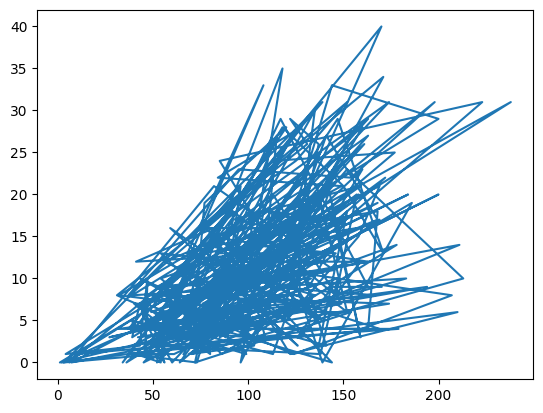

In [3]:
plt.plot(bb["Hits"], bb["HmRun"]);

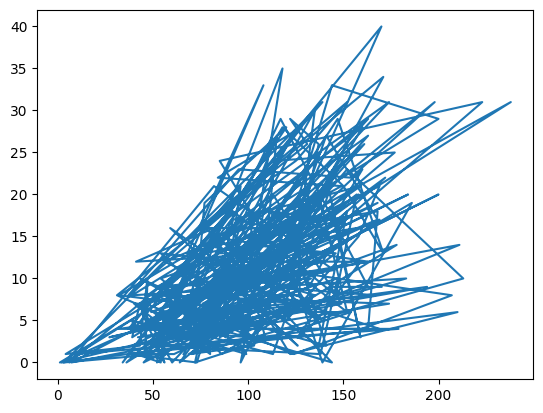

In [4]:
fig, ax = plt.subplots()
ax.plot(bb["Hits"], bb["HmRun"])

`plt.plot` by default plots lineplots. Look at the `fmt` argument in the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html) or use [scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) and plot a scatterplot instead.

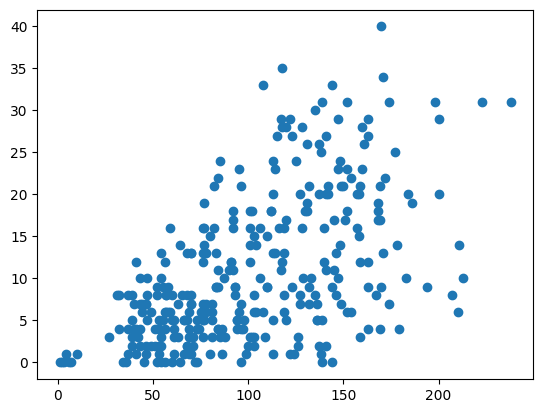

In [5]:
## pyplot
plt.plot(bb["Hits"], bb["HmRun"], "o");

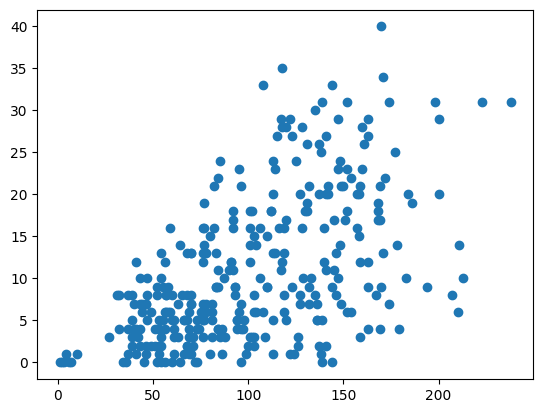

In [6]:
## Axes
fig, ax = plt.subplots()
ax.scatter(bb["Hits"], bb["HmRun"])

When calling plot multiple times without explicitly "closing" the figure, your graphics rendering backend will continue to plot new elements onto the same set of axes. Call `plt.plot` or `plt.scatter` twice, plotting two associations: home runs vs hits, and runs vs hits. Ensure the two associations are different colors, and use 'x' markers for the points in one of the associations.

If using Jupyter, you need code for both plots in the same cells. Each cell restarts the rendering backend.

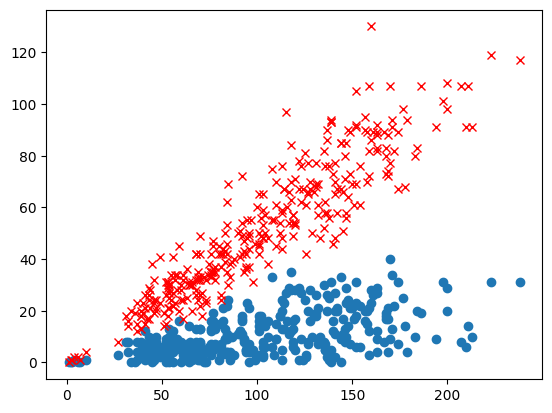

In [7]:
## pyplot
plt.plot(bb["Hits"], bb["HmRun"], "o");
plt.plot(bb["Hits"], bb["Runs"], "rx");

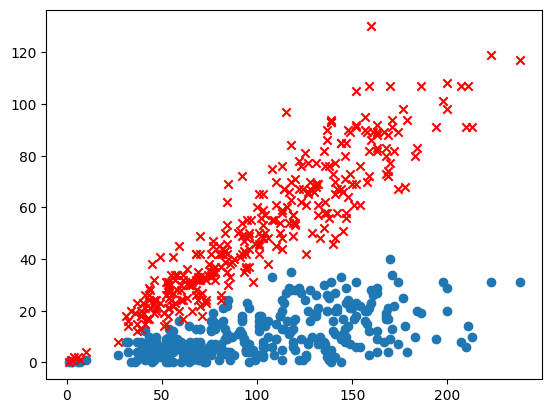

In [8]:
## Axes
fig, ax = plt.subplots()
ax.scatter(bb["Hits"], bb["HmRun"])
ax.scatter(bb["Hits"], bb["Runs"], marker = 'x', c = "red")

#### 2. Labels and Legends

We know that figures are nothing without context. A plot will always have labels and typically a legend if we are using more than one channel of visual encoding. To add labels with pyplot, use `xlabel`, `ylabel` and `title`. With Axes, use `set_xlabel`, `set_ylabel` and `set_title`. These will place text implicitly in the given locations based on your x and y axes.

Text(0.5, 1.0, 'Runs based on number of hits')

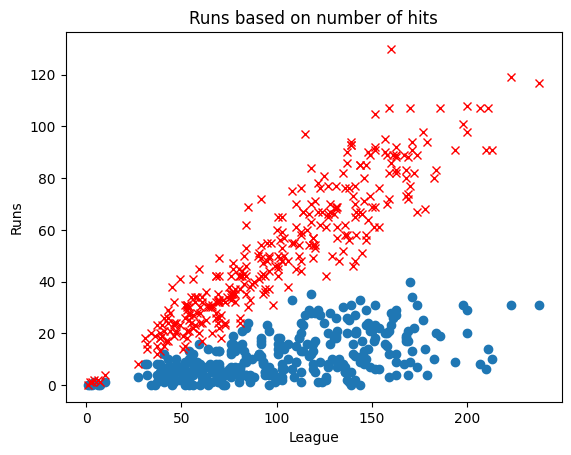

In [9]:
##pyplot
plt.plot(bb["Hits"], bb["HmRun"], "o");
plt.plot(bb["Hits"], bb["Runs"], "rx");
plt.xlabel("League")
plt.ylabel("Runs")
plt.title("Runs based on number of hits")

Text(0.5, 1.0, 'Runs based on number of hits')

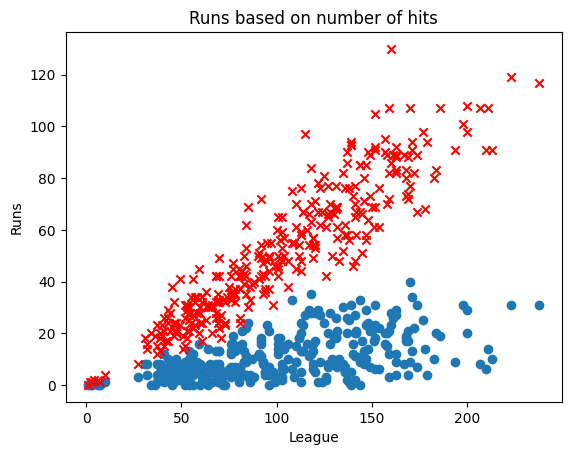

In [10]:
## Axes
fig, ax = plt.subplots()
ax.scatter(bb["Hits"], bb["HmRun"])
ax.scatter(bb["Hits"], bb["Runs"], marker = "x", c = "red")
ax.set_xlabel("League")
ax.set_ylabel("Runs")
ax.set_title("Runs based on number of hits")

C:\Users\ajmue\AppData\Local\Temp\ipykernel_21492\2102366370.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


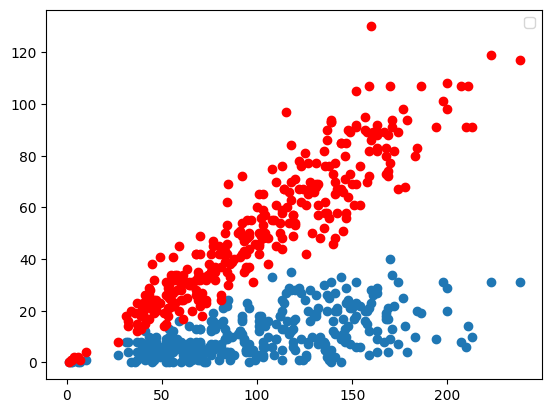

In [11]:
plt.plot(bb["Hits"], bb["HmRun"], "o");
plt.plot(bb["Hits"], bb["Runs"], "ro");
plt.legend()

Now use [legend](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html) to add labels indicating which colored points refer to which y variable. Do this by adding a `label` argument to your `plot` functions. The legend handles will then inherit the styles used in the plot.

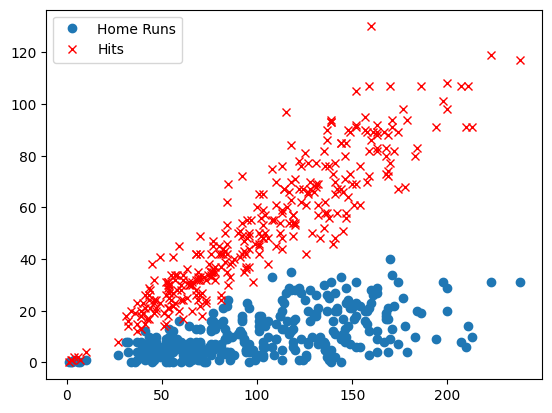

In [12]:
plt.plot(bb["Hits"], bb["HmRun"], "o", label = "Home Runs");
plt.plot(bb["Hits"], bb["Runs"], "rx", label = "Hits");
plt.legend()

Occasionally we need to create a custom legend when `legend` isn't fully capable of inferring the correct aesthetics. To do so, we create "handles" and pass the handles to `legend`. Each handle should be a desired visual style, typically created as a single point or line created with [Line2D](https://matplotlib.org/stable/api/_as_gen/matplotlib.lines.Line2D.html). Use this [reference](https://matplotlib.org/stable/gallery/text_labels_and_annotations/custom_legends.html) for help. 

Below I fit a simple linear model to each associaton and derive predictions across the range of x-values. Plot the lines of best fit on top of your scatterplot.

In [13]:
from sklearn.linear_model import LinearRegression

m1 = LinearRegression().fit(bb[["Hits"]], bb["HmRun"])
m2 = LinearRegression().fit(bb[["Hits"]], bb["Runs"])

x = np.linspace(0,250,250)

y_HmRun = m1.predict(pd.DataFrame(x))
y_Runs = m2.predict(pd.DataFrame(x))

C:\Users\ajmue\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\ajmue\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


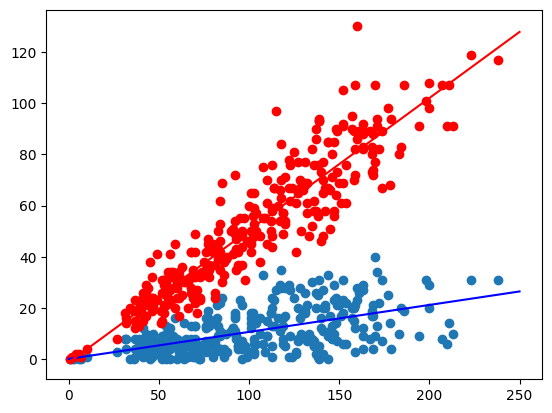

In [14]:
plt.plot(bb["Hits"], bb["HmRun"], "o")
plt.plot(bb["Hits"], bb["Runs"], "ro")
plt.plot(x, y_HmRun, c = "blue")
plt.plot(x, y_Runs, c = "red")

Now create custom handles that include all of the marker type, line, and color for the two predictors.

In [15]:
line1 = plt.Line2D([0], [0], marker='o', color='blue', markersize = 7) 
line2 = plt.Line2D([0], [0], marker='x', color='red', markerfacecolor='red', markersize = 7)

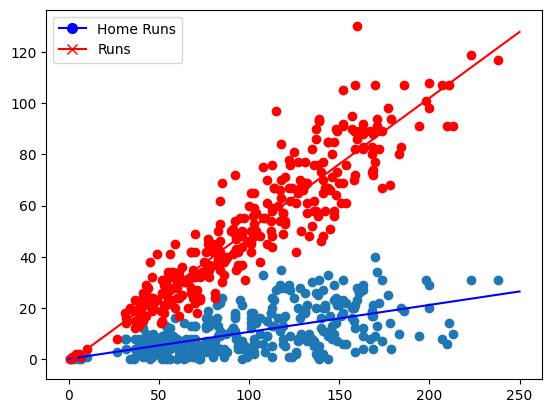

In [16]:
plt.plot(bb["Hits"], bb["HmRun"], "o")
plt.plot(bb["Hits"], bb["Runs"], "ro")
plt.plot(x, y_HmRun, c = "blue")
plt.plot(x, y_Runs, c = "red")
plt.legend(handles = [line1, line2], labels = ["Home Runs", "Runs"])

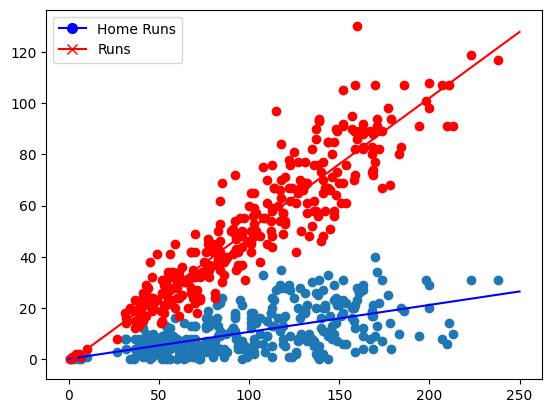

In [17]:
fig, ax = plt.subplots()
ax.plot(bb["Hits"], bb["HmRun"], "o")
ax.plot(bb["Hits"], bb["Runs"], "ro")
ax.plot(x, y_HmRun, c = "blue")
ax.plot(x, y_Runs, c = "red")
ax.legend(handles = [line1, line2], labels = ["Home Runs", "Runs"])

#### 3. Text

Now create a barplot with `bar` of any quantitative variable by League. League should be the x axis. Add the appropriate x, y and title labels.

<BarContainer object of 322 artists>

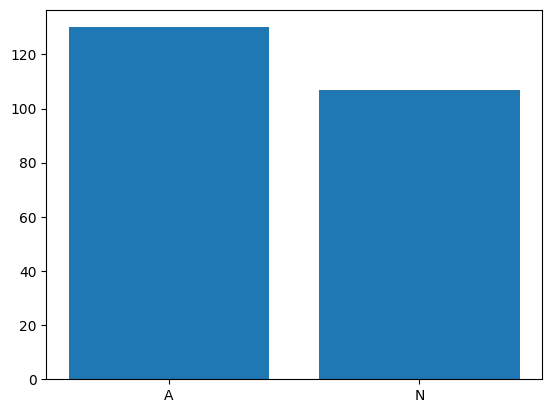

In [18]:
plt.bar(bb["League"], bb["Runs"])

<BarContainer object of 322 artists>

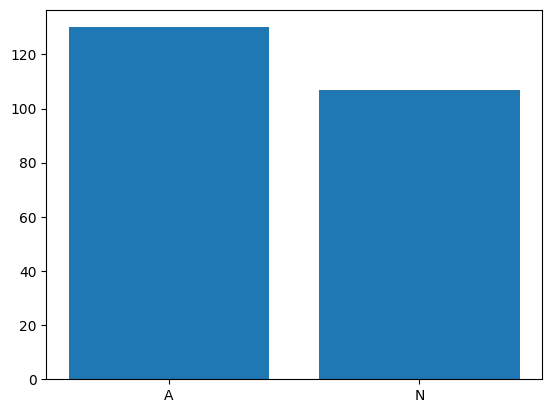

In [19]:
fig, ax = plt.subplots()
ax.bar(bb["League"], bb["Runs"])

What are the values of the bar? Note that the correct answer indicates that the `pyplot` interface contains implicit logic when plotting data.

Your response ...

[text](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html#matplotlib.pyplot.text) let's us place text wherever we want on the plot. Because the x-tick labels aren't very description, add `text` to the top of each of your bars indicating "American" or "National" League. Use `ylim()` to change the y axis limits and provide more room for your labels. 

Text(0.85, 115, 'National')

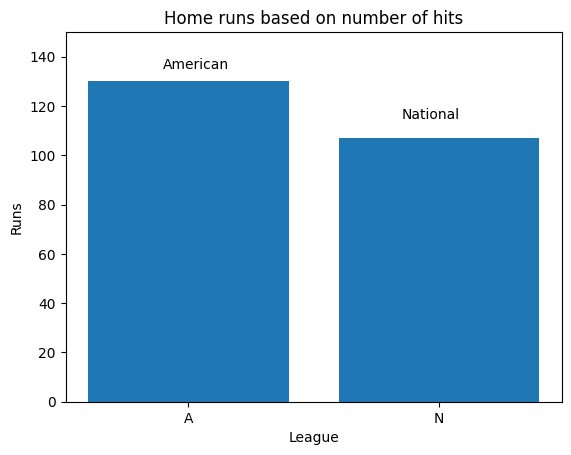

In [20]:
plt.bar(bb["League"], bb["Runs"])
plt.xlabel("League")
plt.ylabel("Runs")
plt.title("Home runs based on number of hits")
plt.ylim([0,150])
plt.text(-0.1, 135, "American")
plt.text(0.85, 115, "National")

Text(0.85, 115, 'National')

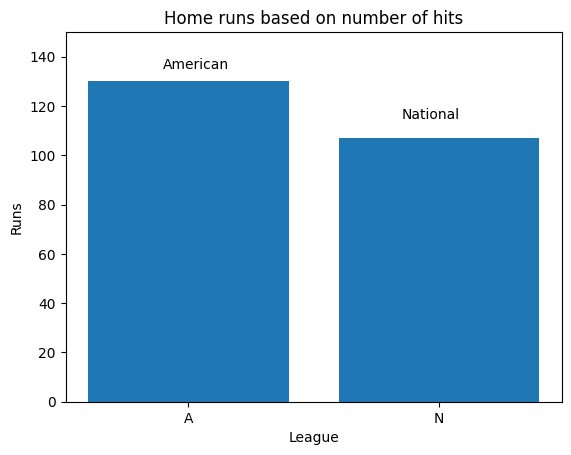

In [21]:
fig, ax = plt.subplots()
ax.bar(bb["League"], bb["Runs"])
ax.set_xlabel("League")
ax.set_ylabel("Runs")
ax.set_title("Home runs based on number of hits")
ax.set_ylim([0,150])
ax.text(-0.1, 135, "American")
ax.text(0.85, 115, "National")

Alternatively, change the x tick labels to "American" and "National" directly (reference the relevant documentation: [pyplot](https://matplotlib.org/stable/api/pyplot_summary.html) and [Axes](https://matplotlib.org/stable/api/axes_api.html#module-matplotlib.axes))

([<matplotlib.axis.XTick at 0x1b8ca83f380>,
 [Text(0, 0, 'American'), Text(1, 0, 'National')])

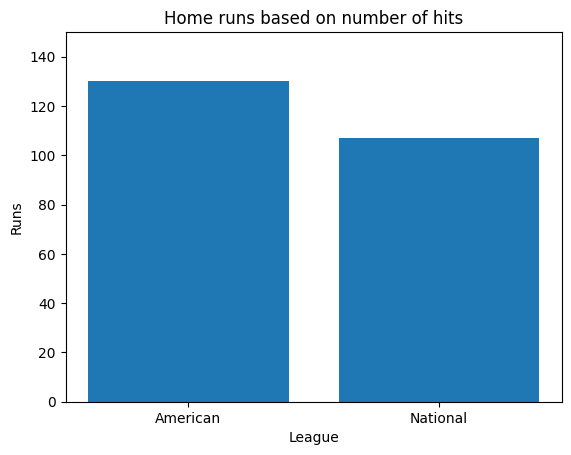

In [22]:
plt.bar(bb["League"], bb["Runs"])
plt.xlabel("League")
plt.ylabel("Runs")
plt.title("Home runs based on number of hits")
plt.ylim([0,150])
plt.xticks(ticks = [0,1], labels = ["American", "National"])

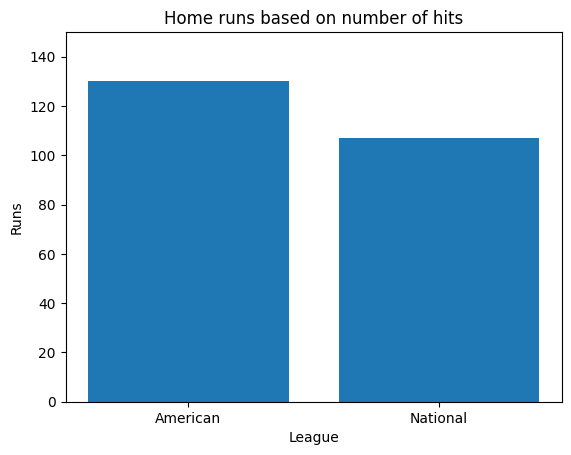

In [23]:
fig, ax = plt.subplots()
ax.bar(bb["League"], bb["Runs"])
ax.set_xlabel("League")
ax.set_ylabel("Runs")
ax.set_title("Home runs based on number of hits")
ax.set_ylim([0,150])
ax.set_xticks(ticks = [0,1], labels = ["American", "National"])

You now know how to add text to your plots and create custom legends. 

#### 4. Subplots

Sometimes it makes sense to plot multiple associations in different subplots rather than on the same plot. This process is referred to as **Small Multiples**. We often do this to avoid overplotting too much information on a single set of axes. First plot the distributions of Runs, RBI and Walks on the same figure using `hist`. 

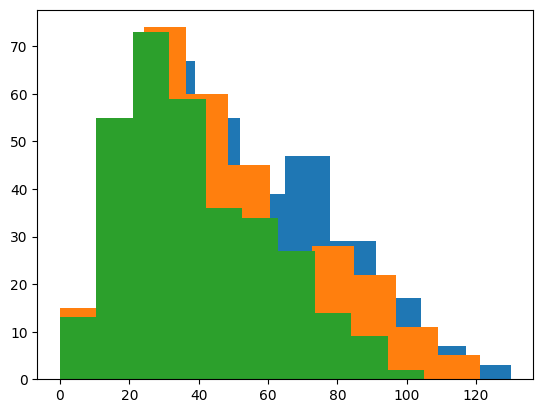

In [24]:
plt.hist(bb["Runs"])
plt.hist(bb["RBI"])
plt.hist(bb["Walks"]);

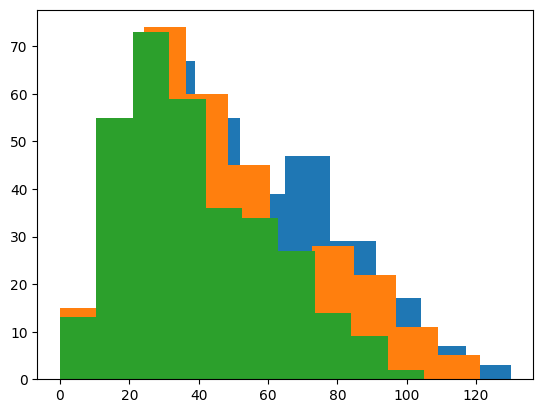

In [25]:
fig, ax = plt.subplots()
ax.hist(bb["Runs"])
ax.hist(bb["RBI"])
ax.hist(bb["Walks"]);

Use `subplot` to create three figures, one for each variable's distribution, in one column and three rows. The first two arguments of `subplot` indicate the dimensionality of your subplots (row, columns, and the third argument indicates which of the frames the following plotting function will plot into. Be sure they all have the same x and y axis limits, and that only the bottom plot has an x axis label.

**Just do the following prompts with "pyplot" for now**

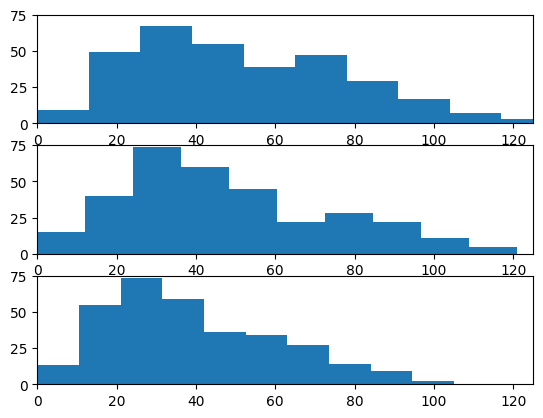

In [26]:
plt.subplot(3,1,1)
plt.hist(bb["Runs"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.subplot(3,1,2)
plt.hist(bb["RBI"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.subplot(3,1,3)
plt.hist(bb["Walks"])
plt.xlim([0,125])
plt.ylim([0,75]);

Because the plots all have the same scales, the x axes on the first two subplots are unnecessary. To remove axis ticks and labels, simply provide an empty list to `xticks` i.e. `plt.xticks([])`.

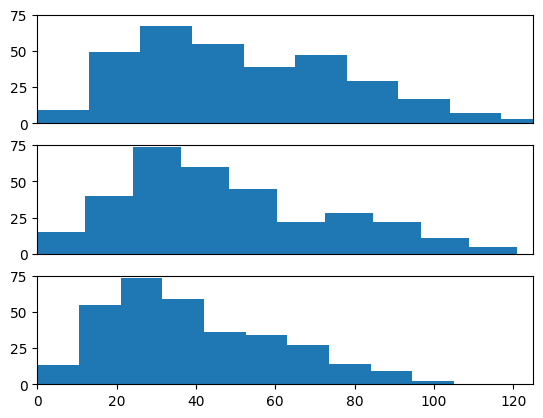

In [27]:
plt.subplot(3,1,1)
plt.hist(bb["Runs"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.xticks([])

plt.subplot(3,1,2)
plt.hist(bb["RBI"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.xticks([])

plt.subplot(3,1,3)
plt.hist(bb["Walks"])
plt.xlim([0,125])
plt.ylim([0,75]);

Add titles to each subplot indicating the variable being plotted. Put the titles on the left side of the plots.

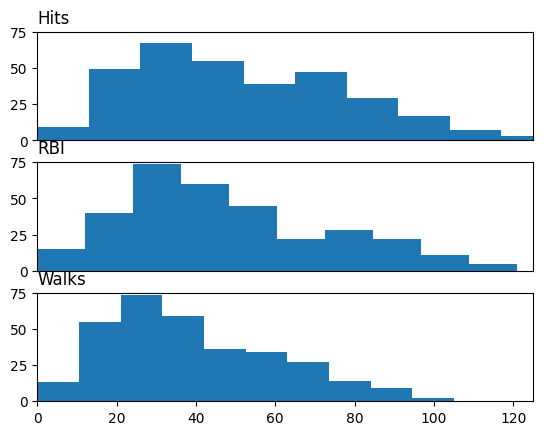

In [28]:
plt.subplot(3,1,1)
plt.hist(bb["Runs"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("Hits", loc = "left")
plt.xticks([])

plt.subplot(3,1,2)
plt.hist(bb["RBI"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("RBI", loc = "left")
plt.xticks([])

plt.subplot(3,1,3)
plt.hist(bb["Walks"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("Walks", loc = "left");

The lower labels are overlapping some of the plots. Use [subplots_adjust](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots_adjust.html) to increase the padding between the three plots so that the titles aren't overlapping any part of the plots.

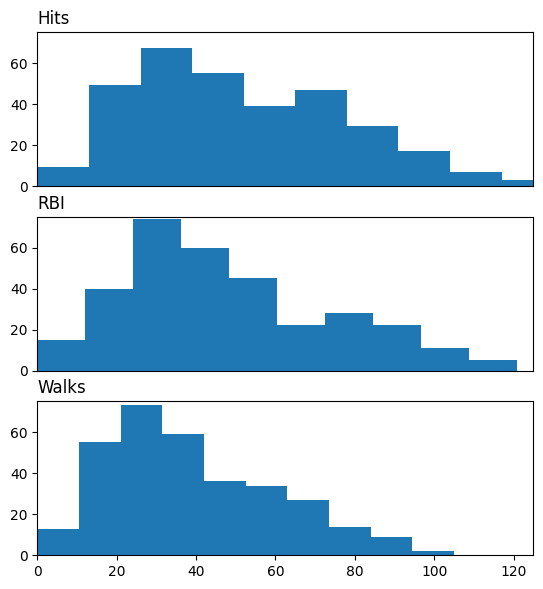

In [29]:
plt.subplots_adjust(top = 1.2)

plt.subplot(3,1,1)
plt.hist(bb["Runs"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("Hits", loc = "left")
plt.xticks([])

plt.subplot(3,1,2)
plt.hist(bb["RBI"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("RBI", loc = "left")
plt.xticks([])

plt.subplot(3,1,3)
plt.hist(bb["Walks"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("Walks", loc = "left");

Finally, add [vertical lines](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.vlines.html) in each subplot representing the median of each distribution. Make them red, dashed and increase their line width.

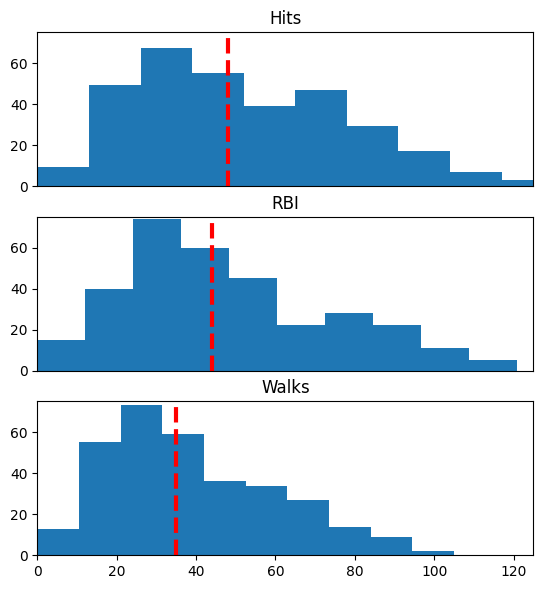

In [30]:
plt.subplots_adjust(top = 1.2)

plt.subplot(3,1,1)
plt.hist(bb["Runs"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("Hits")
plt.xticks([])
plt.axvline(x = np.median(bb["Runs"]), lw = 3, linestyle = "--", color = "red")

plt.subplot(3,1,2)
plt.hist(bb["RBI"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("RBI")
plt.xticks([])
plt.axvline(x = np.median(bb["RBI"]), lw = 3, linestyle = "--", color = "red")

plt.subplot(3,1,3)
plt.hist(bb["Walks"])
plt.xlim([0,125])
plt.ylim([0,75])
plt.title("Walks")
plt.axvline(x = np.median(bb["Walks"]), lw = 3, linestyle = "--", color = "red");

Now create the exact same figure using "Axes". Note that with Axes we use `subplots`, not `subplot`, and the specific axes to apply methods to must be subset with brackets e.g. `ax[0]`.

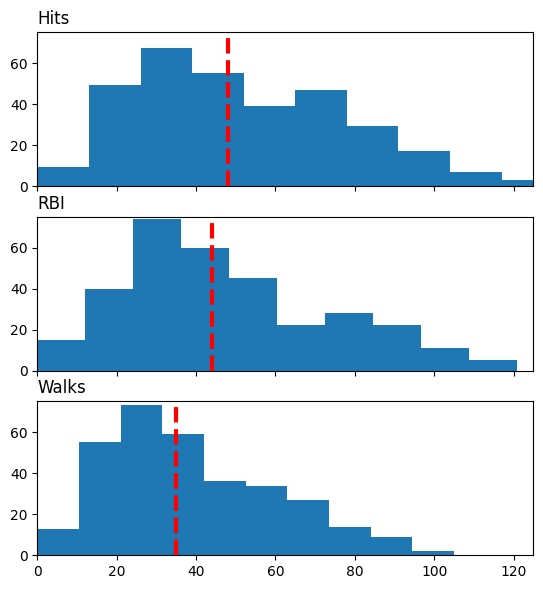

In [31]:
fig, ax = plt.subplots(3,1, sharex = True)
plt.subplots_adjust(top = 1.2)
ax[0].hist(bb["Runs"])
ax[0].set_xlim([0,125])
ax[0].set_ylim([0,75])
ax[0].set_title("Hits", loc = "left")
ax[0].vlines(x = np.median(bb["Runs"]), lw = 3, linestyle = "--", color = "red", ymin = 0, ymax = 200)

ax[1].hist(bb["RBI"])
ax[1].set_xlim([0,125])
ax[1].set_ylim([0,75])
ax[1].set_title("RBI", loc = "left")
ax[1].vlines(x = np.median(bb["RBI"]), lw = 3, linestyle = "--", color = "red", ymin = 0, ymax = 200)

ax[2].hist(bb["Walks"])
ax[2].set_xlim([0,125])
ax[2].set_ylim([0,75]);
ax[2].set_title("Walks", loc = "left")
ax[2].vlines(x = np.median(bb["Walks"]), lw = 3, linestyle = "--", color = "red", ymin = 0, ymax = 200)

This is just the tip of the iceberb. We've touched on many of the most important elements of using each API, but we can't possibly cover everything. Refer to [pyplot](https://matplotlib.org/stable/api/pyplot_summary.html) and [Axes](https://matplotlib.org/stable/api/axes_api.html#module-matplotlib.axes) to view all available functionality (you will need to for the homework!).

Please submit this notebook or your script to the relevant assignment on Canvas. 